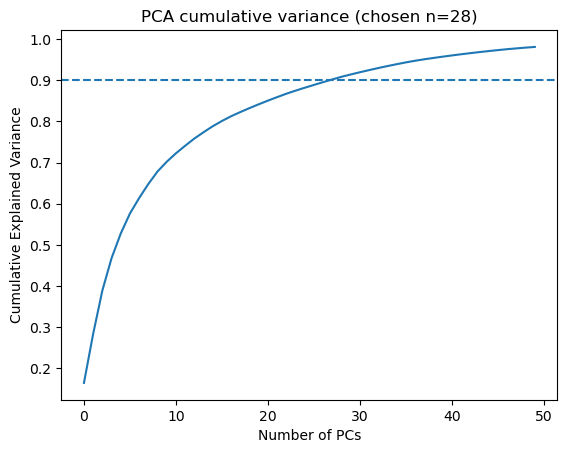

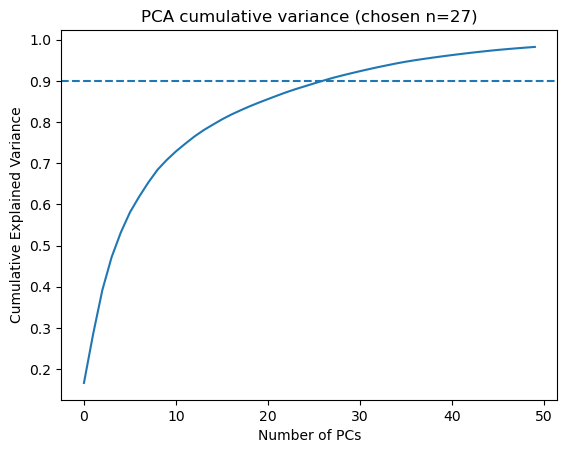

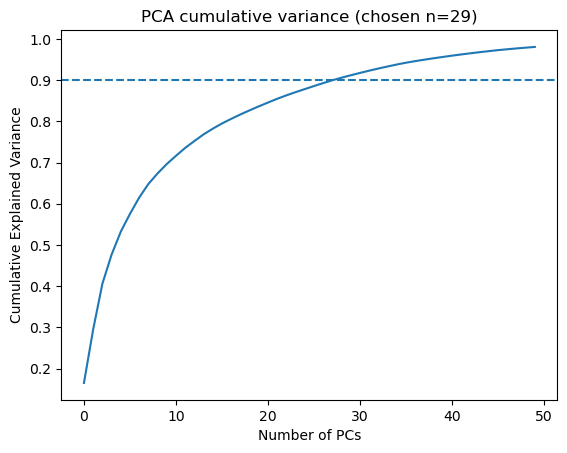

Top silhouettes:
     k        inertia  silhouette
4    6   91450.088637    0.134525
5    7   87619.526070    0.134028
3    5   97597.612587    0.132605
6    8   84306.650704    0.131221
2    4  105064.537590    0.125291
0    2  124432.073983    0.120412
9   11   77461.747912    0.120199
1    3  113928.815450    0.119574
10  12   75646.210216    0.119518
8   10   79570.261844    0.119212


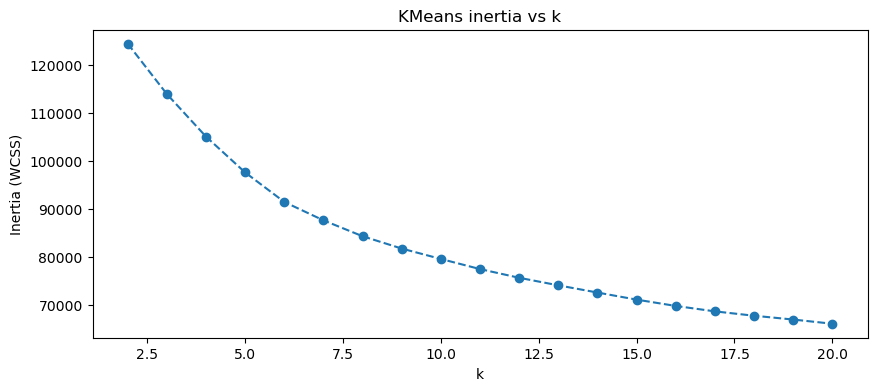

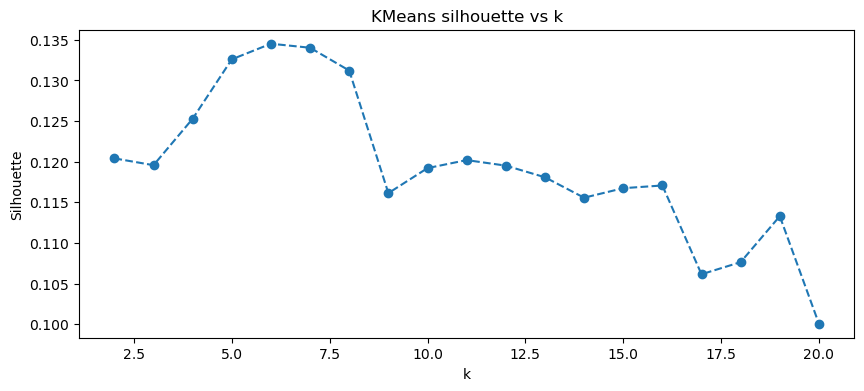

Top stabilities:
     k  stability_ari_mean  stability_ari_std
1    3            0.990461           0.013212
0    2            0.990007           0.012961
4    6            0.985917           0.015428
5    7            0.984570           0.014223
6    8            0.959800           0.046301
3    5            0.939727           0.054484
7    9            0.885776           0.094794
2    4            0.870896           0.192564
11  13            0.809525           0.071165
12  14            0.804838           0.070674


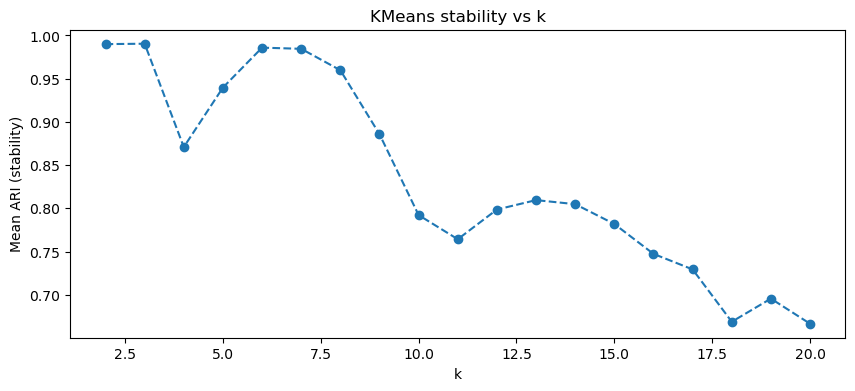

role_id
0     227
1     172
2     182
3     231
4     364
5      96
6     216
7     216
8     102
9     216
10    144
11     82
Name: count, dtype: int64

ROLE 0
Top + traits
pct_pass_to_right_channel      1.842949
pct_pass_from_right_channel    1.840557
passes_BL_per90                1.658372
pct_passes_BL                  1.586888
ttl_passes_BL                  1.464768
pct_pass_right_to_centre       0.944147
pct_passes_FL                  0.795372
passes_L_per90                 0.740570
pct_passes_F                   0.725862
pct_passes_L                   0.695431
Name: 0, dtype: float64

Top - traits
pass_angle_var_left_channel     -1.656151
pct_passes_R                    -1.521607
pct_pass_to_left_channel        -1.381733
pct_pass_from_central_channel   -1.217861
pct_pass_from_left_channel      -1.167382
pct_passes_BR                   -1.139050
pct_pass_left_to_centre         -1.059709
pass_angle_var_overall          -1.058911
pct_pass_to_central_channel     -1.032344
pct_passe

In [16]:
"""
Role taxonomy pipeline (RobustScaler -> PCA -> KMeans) with:
- K scan (inertia + silhouette)
- Stability scan (subsample ARI)
- Leakage tests (drop footedness / drop pct_other_pass)
- Label drift prevention: remap cluster IDs to a reference via centroid matching
- Auto role naming (rule-based) AFTER remap so names are stable
- Archetypal players per role (closest to centroid)
- Variant comparisons (ARI/AMI; permutation-safe)
- Archetype overlap (topN Jaccard)
- Find similar player (cosine in PCA space + explanation using role strengths + feature deltas)

Assumptions:
- parquet has: player_key, player, player_position, dataset (+ passing_feature_columns)
"""

import os
os.environ["OMP_NUM_THREADS"] = "4"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from football_analytics.analyses.passing.features import passing_feature_columns

from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score
from sklearn.metrics import pairwise_distances

# Optional (only if you want centroid-matching remap)
from scipy.optimize import linear_sum_assignment


# ----------------------------
# 0) Load + assemble datasets
# ----------------------------
def load_player_level_datasets():
    paths = {
        "WC2018": "../../../artifacts/features/player_level_wc2018.parquet",
        "WC2022": "../../../artifacts/features/player_level_wc2022.parquet",
        "EURO2024": "../../../artifacts/features/player_level_euro2024.parquet",
        "EURO2020": "../../../artifacts/features/player_level_euro2020.parquet",
        "AFCON2023": "../../../artifacts/features/player_level_afcon2023.parquet",
        "COPA2024": "../../../artifacts/features/player_level_copa2024.parquet",
    }

    dfs = []
    for name, p in paths.items():
        d = pd.read_parquet(p)
        d["dataset"] = name
        dfs.append(d)

    df = pd.concat(dfs, ignore_index=True)
    df = df[df["player_position"] != "Goalkeeper"].copy()
    return df


# ----------------------------
# 1) Feature selection + filter
# ----------------------------
FEATURES = [
    'passes_per_90','short_passes_per_90','medium_passes_per_90','long_passes_per_90',
    'crosses_per90','switches_per90','throughballs_per90','cutbacks_per90','backheels_per90',
    'passes_under_pressure_per90','key_passes_per90','assists_per90','pct_passes_under_pressure',
    'avg_pass_length','std_pass_length','pct_short_pass','pct_med_pass','pct_long_pass',
    'pct_ground_pass','pct_low_pass','pct_high_pass','pct_left_foot_pass','pct_right_foot_pass',
    'pct_head_pass','pct_foot_pass','pct_other_pass','pct_keeper_arm_pass',
    'pct_progressive_passes','pct_lateral_passes','pct_defensive_passes',
    'pct_pass_from_def_third','pct_pass_from_mid_third','pct_pass_from_att_third',
    'pct_pass_from_left_channel','pct_pass_from_central_channel','pct_pass_from_right_channel',
    'pct_pass_to_def_third','pct_pass_to_mid_third','pct_pass_to_left_channel',
    'pct_pass_to_central_channel','pct_pass_to_right_channel',
    'pct_passes_final_third','pct_passes_into_box',
    'pct_pass_from_zone_dl','pct_pass_to_zone_dl','pct_pass_from_zone_dc','pct_pass_to_zone_dc',
    'pct_pass_from_zone_dr','pct_pass_to_zone_dr','pct_pass_from_zone_ml','pct_pass_to_zone_ml',
    'pct_pass_from_zone_mc','pct_pass_to_zone_mc','pct_pass_from_zone_mr','pct_pass_to_zone_mr',
    'pct_pass_from_zone_al','pct_pass_to_zone_al','pct_pass_from_zone_ac','pct_pass_to_zone_ac',
    'pct_pass_from_zone_ar','pct_pass_to_zone_ar',
    'pct_pass_def_to_mid','pct_pass_def_to_att','pct_pass_mid_to_att','pct_pass_mid_to_mid',
    'pct_pass_att_to_mid','pct_pass_def_to_def','pct_pass_att_to_att',
    'pct_pass_left_to_centre','pct_pass_left_to_right','pct_pass_right_to_centre',
    'pct_pass_right_to_left','pct_pass_centre_to_left','pct_pass_centre_to_right',
    'pct_pass_wide_to_box','pct_pass_centre_to_box','pct_pass_def_to_box',
    'ttl_passes_F','pct_passes_F','passes_F_per90',
    'ttl_passes_FR','pct_passes_FR','passes_FR_per90',
    'ttl_passes_R','pct_passes_R','passes_R_per90',
    'ttl_passes_BR','pct_passes_BR','passes_BR_per90',
    'ttl_passes_B','pct_passes_B','passes_B_per90',
    'ttl_passes_BL','pct_passes_BL','passes_BL_per90',
    'ttl_passes_L','pct_passes_L','passes_L_per90',
    'ttl_passes_FL','pct_passes_FL','passes_FL_per90',
    'pass_angle_mean_overall','pass_angle_var_overall',
    'pass_angle_mean_def_third','pass_angle_var_def_third',
    'pass_angle_mean_mid_third','pass_angle_var_mid_third',
    'pass_angle_mean_att_third','pass_angle_var_att_third',
    'pass_angle_mean_left_channel','pass_angle_var_left_channel',
    'pass_angle_mean_centre_channel','pass_angle_var_centre_channel',
    'pass_angle_mean_right_channel','pass_angle_var_right_channel'
]

FOOTEDNESS_FEATURES = ["pct_left_foot_pass", "pct_right_foot_pass"]
ARTEFACTY_FEATURES = ["pct_other_pass"]


def build_model_df(df_raw: pd.DataFrame, features: list[str]):
    passing_cols = passing_feature_columns()
    keep_cols = ["player_key", "player", "player_position", "dataset"] + passing_cols
    df = df_raw[keep_cols].copy()

    # Filters
    df = df[df["player_position"].notna()].copy()
    if "has_minutes" in df.columns:
        df = df[df["has_minutes"] == 1]
    if "has_pass_events" in df.columns:
        df = df[df["has_pass_events"] == 1]
    if "passes_per_90" in df.columns:
        df = df[df["passes_per_90"].fillna(0) > 0]

    feats = [c for c in features if c in df.columns]

    # Backheels: NaN -> 0
    if "backheels_per90" in feats:
        df["backheels_per90"] = df["backheels_per90"].fillna(0.0)

    # Fill remaining NaNs -> 0 (okay for per90/pct features)
    df[feats] = df[feats].fillna(0.0)

    return df.reset_index(drop=True), feats


# ----------------------------------------
# 2) Scaling + PCA
# ----------------------------------------
def fit_pca(X_df: pd.DataFrame, n_components: int | None = None, var_threshold: float = 0.90, random_state: int = 42):
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X_df)

    if n_components is None:
        pca0 = PCA(n_components=min(50, X_scaled.shape[1]), random_state=random_state)
        pca0.fit(X_scaled)
        cum = np.cumsum(pca0.explained_variance_ratio_)
        n_components = int(np.argmax(cum >= var_threshold) + 1)

        plt.figure()
        plt.plot(cum)
        plt.axhline(var_threshold, linestyle="--")
        plt.xlabel("Number of PCs")
        plt.ylabel("Cumulative Explained Variance")
        plt.title(f"PCA cumulative variance (chosen n={n_components})")
        plt.show()

    pca = PCA(n_components=n_components, random_state=random_state)
    X_pca = pca.fit_transform(X_scaled)

    X_pca_df = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(X_pca.shape[1])])
    return scaler, pca, X_pca_df


# ----------------------------------------
# 3) K scans
# ----------------------------------------
def kmeans_scan(X_pca_df: pd.DataFrame, Ks: range, random_state: int = 42, n_init: int = 50):
    rows = []
    for k in Ks:
        km = KMeans(n_clusters=k, init="k-means++", n_init=n_init, random_state=random_state)
        labels = km.fit_predict(X_pca_df)
        sil = np.nan if np.unique(labels).size < 2 else silhouette_score(X_pca_df, labels)
        rows.append({"k": k, "inertia": km.inertia_, "silhouette": sil})
    return pd.DataFrame(rows)


# ----------------------------------------
# 4) Stability scan (subsample ARI)
# ----------------------------------------
def kmeans_stability(X_pca_df: pd.DataFrame, k: int, n_runs: int = 25, frac: float = 0.8, seed: int = 42, n_init: int = 20):
    rng = np.random.default_rng(seed)
    X_np = X_pca_df.to_numpy()
    n = X_np.shape[0]
    scores = []

    for i in range(n_runs):
        idx = rng.choice(n, int(frac * n), replace=False)
        X_sub = X_np[idx]
        l1 = KMeans(n_clusters=k, n_init=n_init, random_state=seed + i).fit_predict(X_sub)
        l2 = KMeans(n_clusters=k, n_init=n_init, random_state=seed + 10_000 + i).fit_predict(X_sub)
        scores.append(adjusted_rand_score(l1, l2))

    return float(np.mean(scores)), float(np.std(scores))


def stability_scan(X_pca_df: pd.DataFrame, Ks: range, **kwargs):
    rows = []
    for k in Ks:
        mean_ari, std_ari = kmeans_stability(X_pca_df, k, **kwargs)
        rows.append({"k": k, "stability_ari_mean": mean_ari, "stability_ari_std": std_ari})
    return pd.DataFrame(rows)


# ----------------------------------------
# 5) Fit roles + profiles
# ----------------------------------------
def fit_roles(df_model: pd.DataFrame, feats: list[str], X_pca_df: pd.DataFrame, k: int,
              random_state: int = 42, n_init: int = 50):
    km = KMeans(n_clusters=k, init="k-means++", n_init=n_init, random_state=random_state)
    labels = km.fit_predict(X_pca_df)

    df_out = df_model.copy()
    df_out["role_id"] = labels

    # Standardize original features for interpretability + centroid matching
    std = StandardScaler()
    X_std = pd.DataFrame(std.fit_transform(df_out[feats]), columns=feats, index=df_out.index)

    # attach standardized features so we can centroid-match in feature space later
    df_out_std = pd.concat([df_out, X_std.add_prefix("z__")], axis=1)

    role_profiles = X_std.groupby(df_out["role_id"])[feats].mean().sort_index()

    return df_out_std, km, role_profiles, std



def print_role_profiles(role_profiles: pd.DataFrame, top_n: int = 10):
    for rid in role_profiles.index:
        s = role_profiles.loc[rid].sort_values(ascending=False)
        print(f"\nROLE {rid}")
        print("Top + traits")
        print(s.head(top_n))
        print("\nTop - traits")
        print(s.tail(top_n).sort_values())


# ----------------------------------------
# 6) Auto role naming (stable AFTER remap)
# ----------------------------------------
def _argmax_label(d: dict) -> tuple[str, float]:
    k = max(d, key=d.get)
    return k, float(d[k])

def role_family(s: pd.Series) -> str:
    """Coarse archetype (can repeat across clusters)."""
    if s.get("pct_pass_def_to_att", 0) > 2.0 and s.get("pct_long_pass", 0) > 1.0:
        return "Direct progressor / long-ball launcher"
    if s.get("throughballs_per90", 0) > 2.0 and s.get("key_passes_per90", 0) > 0.7:
        return "Needle-threading creator (throughball specialist)"
    if s.get("pct_pass_to_right_channel", 0) > 1.3 and s.get("pct_pass_from_right_channel", 0) > 1.3:
        return "Right-lane build-up fullback / outlet"
    if s.get("pct_pass_to_left_channel", 0) > 1.3 and s.get("pct_pass_from_left_channel", 0) > 1.3:
        return "Left-lane shaper / left-footed builder"
    if s.get("pct_pass_from_att_third", 0) > 0.9 and s.get("pct_passes_into_box", 0) > 0.7:
        return "Final-third facilitator (wide-to-box / combo)"
    if s.get("pct_pass_from_mid_third", 0) > 0.8 and s.get("pct_pass_mid_to_mid", 0) > 0.6:
        return "Mid-third circulator / switcher"
    if s.get("passes_per_90", 0) > 0.9 and s.get("short_passes_per_90", 0) > 0.7:
        return "High-volume metronome (possession hub)"
    if s.get("pct_other_pass", 0) > 2.5:
        return "Scrappy press-relief connector"
    if (
        s.get("pct_pass_from_def_third", 0) > 0.9
        and s.get("pct_pass_def_to_def", 0) > 0.9
        and s.get("pct_passes_final_third", 0) < -0.7
    ):
        return "Safe defensive circulator"
    if (
        s.get("pct_pass_from_att_third", 0) > 0.6
        and s.get("pct_passes_under_pressure", 0) > 0.8
        and s.get("pct_short_pass", 0) > 0.8
    ):
        return "Attacking link-up connector"

    return "Unlabelled"


def role_variant_suffix_human(s: pd.Series) -> str:
    """
    Turns role profile fingerprints into short football-y phrases.
    Input `s` is a standardized (z-score) role profile row.
    Output is deterministic + readable.
    """

    # Lane / third bias (only if strong enough)
    from_lane, from_lane_val = _argmax_label({
        "left":   s.get("pct_pass_from_left_channel", 0),
        "central":s.get("pct_pass_from_central_channel", 0),
        "right":  s.get("pct_pass_from_right_channel", 0),
    })
    to_lane, to_lane_val = _argmax_label({
        "left":   s.get("pct_pass_to_left_channel", 0),
        "central":s.get("pct_pass_to_central_channel", 0),
        "right":  s.get("pct_pass_to_right_channel", 0),
    })
    third, third_val = _argmax_label({
        "deep": s.get("pct_pass_from_def_third", 0),
        "mid":  s.get("pct_pass_from_mid_third", 0),
        "high": s.get("pct_pass_from_att_third", 0),
    })

    # Style flags
    switchiness = s.get("pct_pass_left_to_right", 0) + s.get("pct_pass_right_to_left", 0)
    is_switcher = switchiness > 1.2
    is_recycler = s.get("pct_lateral_passes", 0) > 0.7

    is_threader = s.get("throughballs_per90", 0) > 1.0
    is_creator  = s.get("key_passes_per90", 0) > 0.6
    is_box      = (s.get("pct_passes_into_box", 0) > 0.7) or (s.get("pct_pass_wide_to_box", 0) > 0.7)

    is_progressive = s.get("pct_progressive_passes", 0) > 0.8
    is_long = (s.get("pct_long_pass", 0) > 0.9) or (s.get("avg_pass_length", 0) > 0.9)
    is_short = s.get("pct_short_pass", 0) > 0.9
    is_hub = s.get("passes_per_90", 0) > 1.0

    parts = []

    # --- Primary role “location” phrase
    # Only include lane/third if signal is clear
    loc = []
    if third_val > 0.60:
        loc.append({"deep":"Deep", "mid":"Midfield", "high":"Attacking"}[third])
    if from_lane_val > 0.55:
        loc.append({"left":"Left", "central":"Central", "right":"Right"}[from_lane])

    # if lane is unclear but to_lane is, use to_lane
    if not loc and to_lane_val > 0.55:
        loc.append({"left":"Left", "central":"Central", "right":"Right"}[to_lane])

    # Default if nothing triggers
    if loc:
        parts.append(" ".join(loc))
    else:
        parts.append("Mixed")

    # --- Behaviour phrase (ordered by what reads most like football)
    behaviour = []

    # creative / final third stuff
    if is_threader and is_creator:
        behaviour.append("final-ball creator")
    elif is_threader:
        behaviour.append("through-ball specialist")
    elif is_creator:
        behaviour.append("chance creator")

    if is_box:
        behaviour.append("box-feeder")

    # build-up / possession stuff
    if is_hub:
        behaviour.append("tempo hub")
    if is_switcher:
        behaviour.append("switcher")
    elif is_recycler:
        behaviour.append("recycler")

    # directness/length
    if is_progressive and is_long:
        behaviour.append("direct progressor")
    elif is_progressive:
        behaviour.append("line-breaker")
    elif is_long:
        behaviour.append("long passer")
    elif is_short:
        behaviour.append("short connector")

    # keep it short + readable
    if behaviour:
        parts.append(" / ".join(behaviour[:2]))

        # prettier wording
    pretty = {
        "final-ball creator": "final-ball creator",
        "through-ball specialist": "through-ball specialist",
        "chance creator": "chance creator",
        "box-feeder": "box-feeder",
        "tempo hub": "tempo-setter",
        "switcher": "switcher",
        "recycler": "recycler",
        "direct progressor": "direct progressor",
        "line-breaker": "line-breaker",
        "long passer": "long passer",
        "short connector": "short connector",
    }

    if len(parts) == 2:
        # rewrite behaviour words in the second part
        beh = parts[1]
        for k, v in pretty.items():
            beh = beh.replace(k, v)
        parts[1] = beh


    return " — ".join(parts)




def unique_role_name_map(role_profiles: pd.DataFrame) -> dict[int, str]:
    """
    Returns role_id -> unique human-readable role_name.
    Family can repeat, full name cannot.
    Deterministic: same profiles => same names.
    """
    provisional = {}
    for rid in role_profiles.index:
        s = role_profiles.loc[rid]
        fam = role_family(s)
        suffix = role_variant_suffix_human(s)

        # If family is "Unlabelled", fold it into something readable
        if fam == "Unlabelled":
            fam = "Link-up connector"  # default fallback (you can tweak)

        provisional[rid] = f"{fam} — {suffix}"

    # enforce uniqueness deterministically
    seen = {}
    out = {}
    for rid in sorted(provisional.keys()):
        nm = provisional[rid]
        if nm not in seen:
            seen[nm] = 1
            out[rid] = nm
        else:
            seen[nm] += 1
            out[rid] = f"{nm} #{seen[nm]}"

    return out




# ----------------------------------------
# 7) Prevent label drift: remap to reference centroids
# ----------------------------------------
def centroid_remap_feature_space(
    ref_df_roles: pd.DataFrame,
    new_df_roles: pd.DataFrame,
    feats_common: list[str],
) -> dict[int, int]:
    """
    Returns mapping new_label -> ref_label using cosine distance between
    centroids in STANDARDIZED FEATURE SPACE (z__ columns).
    """
    zcols = [f"z__{c}" for c in feats_common]

    # centroids: mean z-scored features per cluster
    ref_centroids = ref_df_roles.groupby("role_id")[zcols].mean().sort_index().to_numpy()
    new_centroids = new_df_roles.groupby("role_id")[zcols].mean().sort_index().to_numpy()

    cost = pairwise_distances(new_centroids, ref_centroids, metric="cosine")
    row_ind, col_ind = linear_sum_assignment(cost)

    # row/col indices correspond to sorted role_id order
    ref_ids = np.array(sorted(ref_df_roles["role_id"].unique()))
    new_ids = np.array(sorted(new_df_roles["role_id"].unique()))

    return {int(new_ids[r]): int(ref_ids[c]) for r, c in zip(row_ind, col_ind)}




def apply_label_map(labels: np.ndarray, label_map: dict[int, int]) -> np.ndarray:
    return np.array([label_map[int(x)] for x in labels], dtype=int)

def remap_df_roles_to_reference_feature_space(
    df_roles: pd.DataFrame,
    feats: list[str],
    ref_df_roles: pd.DataFrame,
    ref_feats: list[str],
):
    feats_common = sorted(set(feats) & set(ref_feats))
    if not feats_common:
        raise ValueError("No common features between variant and reference.")

    zcols = [f"z__{c}" for c in feats_common]

    # sanity checks (better error than a mysterious KeyError)
    missing_ref = [c for c in zcols if c not in ref_df_roles.columns]
    missing_new = [c for c in zcols if c not in df_roles.columns]
    if missing_ref or missing_new:
        raise ValueError(
            f"Missing z__ cols. ref missing: {missing_ref[:5]} | new missing: {missing_new[:5]}"
        )

    label_map = centroid_remap_feature_space(
        ref_df_roles=ref_df_roles,
        new_df_roles=df_roles,
        feats_common=feats_common,
    )

    df_roles = df_roles.copy()
    df_roles["role_id"] = apply_label_map(df_roles["role_id"].to_numpy(), label_map)

    # recompute role_profiles after remap using z-scored features
    X_std_common = df_roles[zcols].copy()
    X_std_common.columns = feats_common
    role_profiles = X_std_common.groupby(df_roles["role_id"])[feats_common].mean().sort_index()

    return df_roles, role_profiles, label_map, feats_common



# ----------------------------------------
# 8) Role strengths + archetypes
# ----------------------------------------
def add_role_strengths(df_roles: pd.DataFrame, X_pca_df: pd.DataFrame, kmeans: KMeans):
    centroids = pd.DataFrame(kmeans.cluster_centers_, columns=X_pca_df.columns)
    dist = pairwise_distances(X_pca_df, centroids, metric="cosine")
    strength = 1 / (1 + dist)

    strength_df = pd.DataFrame(strength, columns=[f"role_{i}_strength" for i in range(centroids.shape[0])])
    out = pd.concat([df_roles.reset_index(drop=True), strength_df], axis=1)
    out["role_strength"] = out.apply(lambda r: r[f"role_{int(r['role_id'])}_strength"], axis=1)
    return out


def top_archetypes(df_roles: pd.DataFrame, n: int = 10):
    for rid in sorted(df_roles["role_id"].unique()):
        sub = df_roles[df_roles["role_id"] == rid].sort_values("role_strength", ascending=False).head(n)
        print("\n", rid, sub["role_name"].iloc[0] if "role_name" in sub.columns else "")
        print(sub[["player", "player_position", "dataset", "role_strength"]])


def archetype_sets(df_roles: pd.DataFrame, top_n: int = 25) -> dict[int, set]:
    sets = {}
    for rid in sorted(df_roles["role_id"].unique()):
        sub = df_roles[df_roles["role_id"] == rid].sort_values("role_strength", ascending=False).head(top_n)
        sets[rid] = set(zip(sub["player_key"], sub["dataset"]))
    return sets


def jaccard(a: set, b: set) -> float:
    if not a and not b:
        return 1.0
    return len(a & b) / len(a | b)


def archetype_overlap(df_a: pd.DataFrame, df_b: pd.DataFrame, top_n: int = 25):
    sets_a = archetype_sets(df_a, top_n=top_n)
    sets_b = archetype_sets(df_b, top_n=top_n)

    rows = []
    for ra, sa in sets_a.items():
        # best match in B for this A role
        best_rb, best_j = None, -1
        for rb, sb in sets_b.items():
            j = jaccard(sa, sb)
            if j > best_j:
                best_rb, best_j = rb, j
        rows.append({"role_a": ra, "role_b": best_rb, f"jaccard_top{top_n}": best_j})

    return pd.DataFrame(rows).sort_values(f"jaccard_top{top_n}", ascending=False)


# ----------------------------------------
# 9) Variant comparison (permutation-safe)
# ----------------------------------------
def compare_clusterings(df_a: pd.DataFrame, df_b: pd.DataFrame, name: str):
    merged = df_a[["player_key","dataset","role_id"]].merge(
        df_b[["player_key","dataset","role_id"]],
        on=["player_key","dataset"],
        suffixes=("_a","_b")
    )
    a = merged["role_id_a"].to_numpy()
    b = merged["role_id_b"].to_numpy()
    return {
        "pair": name,
        "ARI": adjusted_rand_score(a, b),
        "AMI": adjusted_mutual_info_score(a, b),
        "n": int(len(merged)),
    }


# ----------------------------------------
# 10) Find similar player (your old idea, upgraded)
# ----------------------------------------
def build_similarity_index(df_roles: pd.DataFrame, X_pca_df: pd.DataFrame, feats: list[str], X_feat_df: pd.DataFrame):
    """
    Returns a dict holding matrices + lookup helpers for find_similar_player().
    - Similarity computed in PCA space (cosine)
    - Explanations computed from:
        - role strength vectors
        - raw feature vectors (standardized optionally)
    """
    # PCA-space cosine similarity
    Xp = X_pca_df.to_numpy()
    sim = 1 - pairwise_distances(Xp, metric="cosine")

    # role strength columns (role_0_strength etc.)
    role_strength_cols = [c for c in df_roles.columns if c.startswith("role_") and c.endswith("_strength")]
    R = df_roles[role_strength_cols].to_numpy()

    # feature matrix (original features, same order as feats)
    F = X_feat_df[feats].to_numpy()

    name_to_idx = {p: i for i, p in enumerate(df_roles["player"].tolist())}

    return {
        "sim": sim,
        "role_strength_cols": role_strength_cols,
        "R": R,
        "F": F,
        "feats": feats,
        "name_to_idx": name_to_idx,
    }


def find_similar_player(
    player_name: str,
    df_roles: pd.DataFrame,
    index_obj: dict,
    top_n: int = 10,
    role_topk: int = 3,
    diff_topk: int = 8,
):
    """
    Output:
    - similar players by PCA-space cosine similarity
    - shared strongest roles (by role strength)
    - biggest feature differences (absolute deltas)
    """
    if player_name not in index_obj["name_to_idx"]:
        raise ValueError(f"Player not found: {player_name}")

    i = index_obj["name_to_idx"][player_name]
    sim = index_obj["sim"][i].copy()
    sim[i] = -np.inf  # exclude self

    order = np.argsort(sim)[::-1][:top_n]
    rows = []

    role_cols = index_obj["role_strength_cols"]
    R = index_obj["R"]
    F = index_obj["F"]
    feats = index_obj["feats"]

    # player's top roles
    i_role_order = np.argsort(R[i])[::-1]
    i_top_roles = [role_cols[j].replace("_strength","").replace("role_","") for j in i_role_order[:role_topk]]
    i_top_role_names = df_roles.loc[i, "role_name"] if "role_name" in df_roles.columns else str(df_roles.loc[i, "role_id"])

    for j in order:
        j_role_order = np.argsort(R[j])[::-1]
        j_top_roles = [role_cols[t].replace("_strength","").replace("role_","") for t in j_role_order[:role_topk]]

        # overlap of top role IDs (as strings)
        shared = sorted(set(i_top_roles) & set(j_top_roles))
        shared_roles = []
        for rid_str in shared:
            rid = int(rid_str)
            nm = df_roles[df_roles["role_id"] == rid]["role_name"].iloc[0] if "role_name" in df_roles.columns else str(rid)
            shared_roles.append(nm)

        # biggest feature deltas
        deltas = np.abs(F[j] - F[i])
        top_idx = np.argsort(deltas)[::-1][:diff_topk]
        biggest = [f"{feats[t]} ({F[j][t]-F[i][t]:+.3f})" for t in top_idx]

        rows.append({
            "player": df_roles.loc[j, "player"],
            "dataset": df_roles.loc[j, "dataset"],
            "player_position": df_roles.loc[j, "player_position"],
            "similarity": float(sim[j]),
            "shared_roles": ", ".join(shared_roles) if shared_roles else "(none in top roles)",
            "biggest_differences": "; ".join(biggest),
        })

    return pd.DataFrame(rows)


# ----------------------------------------
# 11) Run variant (used for full / nofoot / noother)
# ----------------------------------------
def run_variant(
    df_raw,
    features,
    drop_features=None,
    k_final=12,
    var_threshold=0.90,
    random_state=42,
    ref=None,
):
    drop_features = set(drop_features or [])
    df_model, feats = build_model_df(df_raw, features)
    feats = [c for c in feats if c not in drop_features]

    X_feat_df = df_model[feats]
    scaler, pca, X_pca_df = fit_pca(
        X_feat_df, n_components=None, var_threshold=var_threshold, random_state=random_state
    )

    # Fit KMeans in this variant's PCA space
    df_roles, km, role_profiles, std = fit_roles(
        df_model, feats, X_pca_df, k=k_final, random_state=random_state
    )

    label_map = None
    feats_common = None

    # ✅ Remap cluster IDs into reference ID space (FEATURE SPACE, not PCA)
    if ref is not None:
        df_roles, role_profiles, label_map, feats_common = remap_df_roles_to_reference_feature_space(
            df_roles=df_roles,
            feats=feats,
            ref_df_roles=ref["df_roles"],
            ref_feats=ref["feats"],
        )

    # Name roles AFTER remap (so names are stable in ref label-space)
    role_name_map = unique_role_name_map(role_profiles)
    df_roles["role_name"] = df_roles["role_id"].map(role_name_map)

    # Strengths: must use THIS variant's km + X_pca_df (same PCA space)
    df_roles = add_role_strengths(df_roles, X_pca_df, km)

    return {
        "df_roles": df_roles,
        "role_profiles": role_profiles,
        "role_name_map": role_name_map,
        "label_map": label_map,
        "feats_common": feats_common,
        "scaler": scaler,
        "pca": pca,
        "kmeans": km,        # ✅ always the variant km (correct space)
        "std": std,
        "X_pca_df": X_pca_df,
        "X_feat_df": X_feat_df,
        "feats": feats,
    }




# =========================
# MAIN RUN
# =========================
df_raw = load_player_level_datasets()

Ks = range(2, 21)
K_FINAL = 12

# ---- Fit base
base = run_variant(df_raw, FEATURES, drop_features=None, k_final=K_FINAL, var_threshold=0.90, ref=None)
nofoot = run_variant(df_raw, FEATURES, drop_features=FOOTEDNESS_FEATURES, k_final=K_FINAL, var_threshold=0.90, ref=base)
noother = run_variant(df_raw, FEATURES, drop_features=ARTEFACTY_FEATURES, k_final=K_FINAL, var_threshold=0.90, ref=base)

# K selection plots (reuse the PCA from base so scans are consistent)
scan = kmeans_scan(base["X_pca_df"], Ks)
print("Top silhouettes:")
print(scan.sort_values("silhouette", ascending=False).head(10))

plt.figure(figsize=(10,4))
plt.plot(scan["k"], scan["inertia"], marker="o", linestyle="--")
plt.xlabel("k"); plt.ylabel("Inertia (WCSS)"); plt.title("KMeans inertia vs k")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(scan["k"], scan["silhouette"], marker="o", linestyle="--")
plt.xlabel("k"); plt.ylabel("Silhouette"); plt.title("KMeans silhouette vs k")
plt.show()

stab = stability_scan(base["X_pca_df"], Ks, n_runs=25, frac=0.8, seed=42, n_init=20)
print("Top stabilities:")
print(stab.sort_values("stability_ari_mean", ascending=False).head(10))

plt.figure(figsize=(10,4))
plt.plot(stab["k"], stab["stability_ari_mean"], marker="o", linestyle="--")
plt.xlabel("k"); plt.ylabel("Mean ARI (stability)"); plt.title("KMeans stability vs k")
plt.show()

print(base["df_roles"]["role_id"].value_counts().sort_index())
print_role_profiles(base["role_profiles"], top_n=10)
top_archetypes(base["df_roles"], n=10)

# Permutation-safe comparisons
print("Variant comparison (proper, permutation-safe):")
print(compare_clusterings(base["df_roles"], nofoot["df_roles"], "full vs nofoot"))
print(compare_clusterings(base["df_roles"], noother["df_roles"], "full vs noother"))

# Archetype overlap tables
print("\nArchetype overlap full vs nofoot (top25):")
print(archetype_overlap(base["df_roles"], nofoot["df_roles"], top_n=25).head(12))

print("\nArchetype overlap full vs noother (top25):")
print(archetype_overlap(base["df_roles"], noother["df_roles"], top_n=25).head(12))

# ---- Build similarity index + example query
sim_index = build_similarity_index(
    df_roles=base["df_roles"],
    X_pca_df=base["X_pca_df"],
    feats=base["feats"],
    X_feat_df=base["X_feat_df"],
)

# Example:
# result = find_similar_player("Cody Mathès Gakpo", base["df_roles"], sim_index, top_n=10)
# print(result)


In [57]:
df_model[df_model["player"].str.contains("Messi", case=False, na=False)]['player'].unique()


array(['Lionel Andrés Messi Cuccittini'], dtype=object)